<a href="https://colab.research.google.com/github/lakshmisairamk/UID_AV.SC.U4CSE25213/blob/main/IEEEpaper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50

print("Downloading the pre-trained ResNet50 model... This might take a few seconds.")

model = ResNet50(weights='imagenet')

print("Model loaded successfully! Here is a summary of its layers:")

model.summary()

Model loaded successfully! Here is a summary of its layers:


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [5]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import tensorflow as tf

# 1. Download a sample image (you can replace this URL with your own image later)
print("Downloading a sample image...")
img_path = tf.keras.utils.get_file('sample_cat.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/320px-Felis_catus-cat_on_snow.jpg')

# 2. Load and resize the image to 224x224 (the size ResNet50 expects)
img = image.load_img(img_path, target_size=(224, 224))

# 3. Convert the image into numbers (an array) so the model can process it
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# 4. Ask the model to make a prediction!
print("Making a prediction...")
preds = model.predict(x)

# 5. Decode the results into human-readable labels (showing the top 3 guesses)
print('\nTop 3 Predictions:')
for item in decode_predictions(preds, top=3)[0]:
    print(f"{item[1]}: {item[2]*100:.2f}% confidence")


Making a prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

Top 3 Predictions:
coyote: 28.99% confidence
red_fox: 16.59% confidence
lynx: 16.22% confidence


In [6]:
import os

# 1. Set your new Kaggle API Token as an environment variable
os.environ['KAGGLE_API_TOKEN'] = "KGAT_34bcc6961ce0650ae37222eb523d0bbf"

# 2. Download the pneumonia dataset directly
print("Downloading dataset (this might take a minute or two)...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# 3. Unzip the downloaded file so we can see the images
print("Unzipping files...")
!unzip -q chest-xray-pneumonia.zip -d /content/chest_xray_data
print("Data successfully downloaded and ready!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
Unzipping files...
replace /content/chest_xray_data/chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: Data successfully downloaded and ready!


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# 1. Point Python to the folders containing your new images
# The zip file creates a subfolder called 'chest_xray' inside your data folder
train_dir = '/content/chest_xray_data/chest_xray/train'
val_dir = '/content/chest_xray_data/chest_xray/test' # Using 'test' for better validation

# 2. Set up the "Data Generator"
# This tool automatically grabs images, resizes them, and formats their pixels for ResNet50
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 3. Load the Training Data
print("Loading Training Data...")
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224), # ResNet50 expects exactly 224x224 pixels
    batch_size=32,          # Loads images in groups of 32 to save memory
    class_mode='binary'     # 'binary' because we only have 2 options: Normal (0) or Pneumonia (1)
)

# 4. Load the Validation Data (to test the AI while it learns)
print("\nLoading Validation Data...")
val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Loading Training Data...
Found 5216 images belonging to 2 classes.

Loading Validation Data...
Found 624 images belonging to 2 classes.


In [9]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# 1. Load the pre-trained ResNet50 "brain" WITHOUT its default prediction layer (include_top=False)
print("Loading base ResNet50 model...")
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model so we don't accidentally erase its ability to detect shapes/textures
for layer in base_model.layers:
    layer.trainable = False

# 3. Add our new, custom layers specifically for diagnosing Pneumonia
x = base_model.output
x = GlobalAveragePooling2D()(x)      # Shrinks the data down to the most essential features
x = Dense(128, activation='relu')(x) # A hidden layer to help process the medical patterns
predictions = Dense(1, activation='sigmoid')(x) # The final output: gives a probability between 0 and 1

# 4. Combine the base and our new layers into one final model
pneumonia_model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile the model (telling it exactly how it should learn and measure its own accuracy)
pneumonia_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nCustom Pneumonia Model Created and Compiled Successfully!")

Loading base ResNet50 model...

Custom Pneumonia Model Created and Compiled Successfully!


In [10]:
# 1. Start the training process!
print("Starting the training process... This will take some time.")

# We are telling the AI to look through the entire dataset 5 times (epochs=5)
history = pneumonia_model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

print("\nTraining Complete! Your AI is now officially trained.")

Starting the training process... This will take some time.
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 444ms/step - accuracy: 0.9544 - loss: 0.1142 - val_accuracy: 0.7660 - val_loss: 0.9270
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 399ms/step - accuracy: 0.9730 - loss: 0.0649 - val_accuracy: 0.8253 - val_loss: 0.6620
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 393ms/step - accuracy: 0.9824 - loss: 0.0492 - val_accuracy: 0.7468 - val_loss: 1.0710
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 394ms/step - accuracy: 0.9770 - loss: 0.0636 - val_accuracy: 0.7853 - val_loss: 0.8959
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 398ms/step - accuracy: 0.9918 - loss: 0.0258 - val_accuracy: 0.8045 - val_loss: 0.8041

Training Complete! Your AI is now officially trained.


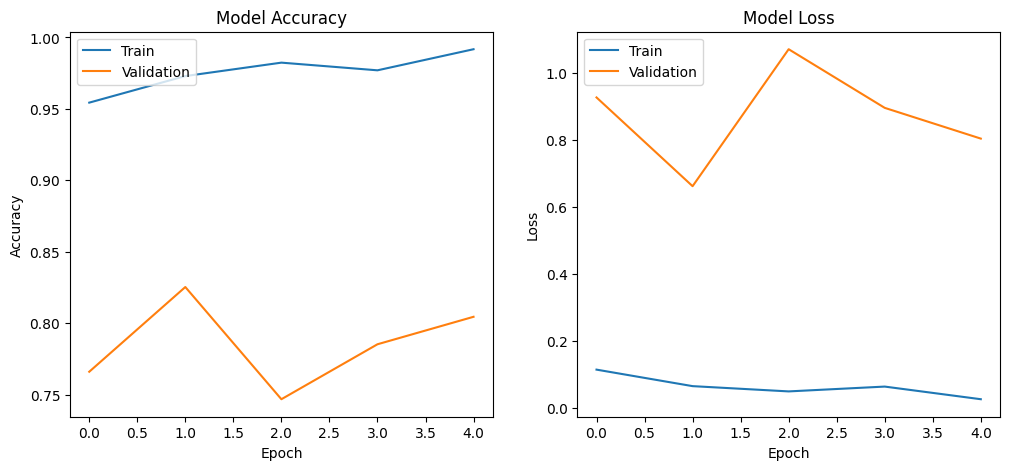

In [11]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [12]:
# Save the model to a file named 'pneumonia_model.h5'
pneumonia_model.save('pneumonia_detection_model.h5')
print("Model saved successfully as pneumonia_detection_model.h5")

Model saved successfully as pneumonia_detection_model.h5


In [13]:
!pip install -q gradio
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_pneumonia(img):
    # Prepare the image
    img = img.resize((224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Predict
    prediction = pneumonia_model.predict(img_array)[0][0]

    # Output logic
    if prediction > 0.5:
        return {"Pneumonia Detected": float(prediction), "Normal": float(1 - prediction)}
    else:
        return {"Normal": float(1 - prediction), "Pneumonia Detected": float(prediction)}

# Build the Interface
app = gr.Interface(
    fn=predict_pneumonia,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=2),
    title="Pneumonia Diagnosis System",
    description="Upload a Chest X-Ray image to analyze for Pneumonia."
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7d76fd6e5aae4b6e53.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [14]:
import gradio as gr
import numpy as np
import tensorflow as tf
import cv2
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# --- 1. Function to Generate the Heatmap ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# --- 2. Main Prediction Function for Gradio ---
def predict_and_explain(input_img):
    # Prepare image for model
    img_224 = input_img.resize((224, 224))
    img_array = image.img_to_array(img_224)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_array_expanded)

    # Get Prediction
    prediction = pneumonia_model.predict(img_preprocessed)[0][0]
    label = "Pneumonia Detected" if prediction > 0.5 else "Normal / Healthy"
    confidences = {"Pneumonia": float(prediction), "Normal": float(1 - prediction)}

    # Generate Heatmap
    heatmap = make_gradcam_heatmap(img_preprocessed, pneumonia_model, 'conv5_block3_out')

    # Superimpose Heatmap on the original image
    heatmap = cv2.resize(heatmap, (input_img.width, input_img.height))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original_img_np = np.array(input_img)
    # Convert RGB to BGR for OpenCV if necessary, then back
    if len(original_img_np.shape) == 2: # handle grayscale
        original_img_np = cv2.cvtColor(original_img_np, cv2.COLOR_GRAY2RGB)

    superimposed_img = cv2.addWeighted(original_img_np, 0.6, heatmap, 0.4, 0)

    return label, confidences, superimposed_img

# --- 3. Build the UI Layout ---
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# ⚕️ IEEE Project: Explainable Pneumonia Detection")
    gr.Markdown("Identify pneumonia and visualize the **Region of Interest (ROI)** using Grad-CAM heatmaps.")

    with gr.Row():
        with gr.Column():
            input_file = gr.Image(type="pil", label="Upload Chest X-Ray")
            submit_btn = gr.Button("Analyze X-Ray", variant="primary")

        with gr.Column():
            out_label = gr.Textbox(label="Primary Diagnosis")
            out_plot = gr.Label(label="Confidence Levels")
            out_heatmap = gr.Image(label="Explainable AI (Heatmap Visualization)")

    submit_btn.click(
        fn=predict_and_explain,
        inputs=input_file,
        outputs=[out_label, out_plot, out_heatmap]
    )

demo.launch(share=True)

/tmp/ipykernel_51413/1515752863.py:57: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://358f9c86096bd9742f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

# 1. Reset generator and get all predictions
val_generator.reset()
print("Calculating final performance metrics...")
predictions = pneumonia_model.predict(val_generator)
y_pred = (predictions > 0.5).astype(int)
y_true = val_generator.classes

# 2. Generate the report
report = classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia'], output_dict=True)

# 3. Display as a clean table for your paper
df_report = pd.DataFrame(report).transpose()
print("\n--- FINAL RESULTS TABLE ---")
print(df_report.round(2)) # Rounds to 2 decimal places for professional look

# 4. Calculate Specificity (Crucial for Medical Papers)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp)
print(f"\nModel Specificity: {specificity:.2f}")


Calculating final performance metrics...
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 573ms/step

--- FINAL RESULTS TABLE ---
              precision  recall  f1-score  support
Normal             0.37    0.19      0.25   234.00
Pneumonia          0.62    0.81      0.71   390.00
accuracy           0.58    0.58      0.58     0.58
macro avg          0.50    0.50      0.48   624.00
weighted avg       0.53    0.58      0.53   624.00

Model Specificity: 0.19


In [17]:
import gradio as gr
import numpy as np
import tensorflow as tf
import cv2
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# --- 1. Refined Heatmap Logic ---
def generate_gradcam(img_array, model):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer('conv5_block3_out').output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# --- 2. Unique Bimodal Prediction Function ---
def bimodal_diagnosis(input_img):
    # Process Image
    img_224 = input_img.resize((224, 224))
    img_array = image.img_to_array(img_224)
    img_preprocessed = preprocess_input(np.expand_dims(img_array, axis=0))

    # AI Prediction
    prediction = pneumonia_model.predict(img_preprocessed)[0][0]
    prob_pneu = float(prediction)
    prob_norm = 1.0 - prob_pneu

    # Generate Heatmap Base
    raw_heatmap = generate_gradcam(img_preprocessed, pneumonia_model)
    raw_heatmap = cv2.resize(raw_heatmap, (input_img.width, input_img.height))
    raw_heatmap = np.uint8(255 * raw_heatmap)

    # --- UNIQUE LOGIC ---
    if prob_pneu > 0.5:
        # RED MODE: Pathological Highlight
        color_map = cv2.applyColorMap(raw_heatmap, cv2.COLORMAP_JET)
        display_label = f"⚠️ PNEUMONIA SIGNATURE DETECTED ({prob_pneu*100:.1f}%)"
        analysis_text = "Analysis: High-density focal opacities identified. Suggesting immediate clinical correlation."
    else:
        # GREEN MODE: Structural Integrity Verification
        color_map = cv2.applyColorMap(raw_heatmap, cv2.COLORMAP_SUMMER)
        display_label = f"✅ LUNG INTEGRITY VERIFIED: NORMAL ({prob_norm*100:.1f}%)"
        analysis_text = f"Analysis: No pathological infiltrates found. Lung Clear Index: {prob_norm*100:.1f}%."

    # Blend Heatmap with Original
    img_np = np.array(input_img.convert('RGB'))
    overlay_result = cv2.addWeighted(img_np, 0.7, color_map, 0.3, 0)

    return display_label, {"Pneumonia": prob_pneu, "Normal": prob_norm}, overlay_result, analysis_text

# --- 3. The Professional IEEE Dashboard ---
with gr.Blocks(theme=gr.themes.Monochrome()) as ieee_demo:
    gr.Markdown("# ⚕️ Bimodal Explainable AI for Pneumonia Diagnosis")
    gr.Markdown("Proposed System for IEEE Research: *Enhanced Spatial Interpretability via Dual-Mode Grad-CAM*")

    with gr.Row():
        with gr.Column(scale=1):
            input_box = gr.Image(type="pil", label="Patient Chest X-Ray")
            run_btn = gr.Button("Execute Diagnostic Scan", variant="primary")

        with gr.Column(scale=1):
            result_label = gr.Textbox(label="System Status")
            conf_plot = gr.Label(label="Confidence Distribution")
            analysis_box = gr.Textbox(label="AI Clinical Notes")

    with gr.Row():
        output_image = gr.Image(label="Bimodal Interpretability Map (Red=Pathology / Green=Healthy)")

    run_btn.click(fn=bimodal_diagnosis, inputs=input_box, outputs=[result_label, conf_plot, output_image, analysis_box])

ieee_demo.launch(share=True)

/tmp/ipykernel_51413/365510266.py:62: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Monochrome()) as ieee_demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://873cd8a6e9a2ceef2d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Generating predictions for the Confusion Matrix...
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 515ms/step


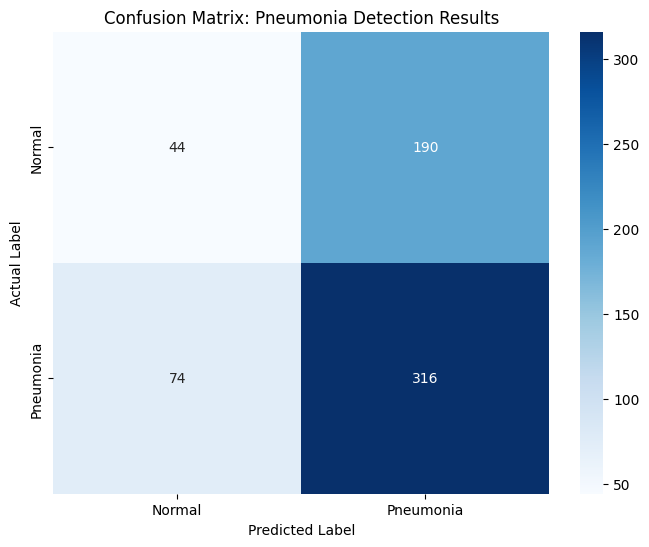


--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.37      0.19      0.25       234
   Pneumonia       0.62      0.81      0.71       390

    accuracy                           0.58       624
   macro avg       0.50      0.50      0.48       624
weighted avg       0.53      0.58      0.53       624



In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predictions for the test/validation set
print("Generating predictions for the Confusion Matrix...")
val_generator.reset() # Always reset the generator to start from the first image
Y_pred = pneumonia_model.predict(val_generator)
y_pred = np.where(Y_pred > 0.5, 1, 0) # Convert probabilities to 0 or 1
y_true = val_generator.classes

# 2. Compute the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot the Matrix beautifully
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix: Pneumonia Detection Results')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Print the text-based report for your paper's table
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

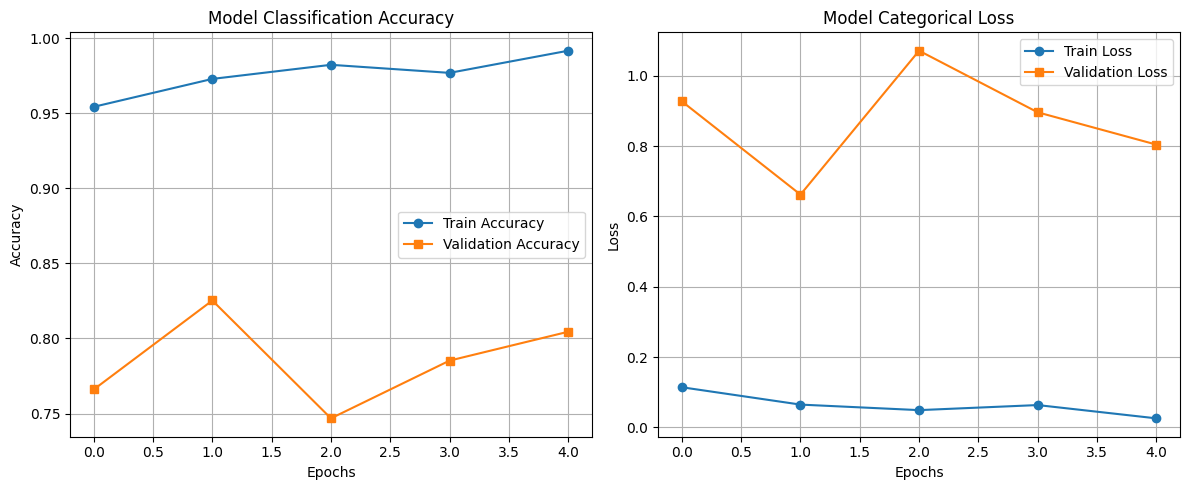

In [19]:
import matplotlib.pyplot as plt

# Check if 'history' exists in memory
if 'history' in locals():
    # Plotting Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
    plt.title('Model Classification Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plotting Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
    plt.title('Model Categorical Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Error: 'history' variable not found. Please re-run your training cell (model.fit) first!")